# Cao 2025 EV fleet telemetry from three manufacturers

This notebook lists the vehicles in the Zenodo release, opens one QAS vehicle's main table (vin_2) as released, and plots one cell voltage. It makes no diagnosis. The files carry no column names, units or timestamps, so the column names here are the loader's inferred names. `notebooks/cao_in_depth.ipynb` explains every column and the checks behind each name.

## 1. Released units

This step lists what `systems('cao')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('cao')
display(released)

,brand,vehicle,source_zip,vin_1,vin_2,vin_3,label
0,DTI,0,DTI.zip,True,True,True,0.0
1,DTI,1,DTI.zip,True,True,True,0.0
2,DTI,2,DTI.zip,True,True,True,0.0
3,DTI,3,DTI.zip,True,True,True,0.0
4,DTI,4,DTI.zip,True,True,True,0.0
...,...,...,...,...,...,...,...
509,QAS,388,QAS_5.zip,True,True,True,1.0
510,QAS,389,QAS_5.zip,True,True,True,1.0
511,QAS,390,QAS_5.zip,True,True,True,1.0
512,QAS,391,QAS_5.zip,True,True,True,1.0


The release has 514 vehicles, one row each, with the archive it sits in, which of the three files it has, and its label (0 healthy, 1 faulty, empty where the authors gave none). The rows shown run from DTI vehicle 0 to QAS vehicle 392.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('cao', brand='QAS', vehicle='189', names='inferred')
print(frame.shape)
display(frame.head())

(32649, 225)


,pack_state_a,pack_state_b,cell_v_001,cell_v_002,cell_v_003,cell_v_004,cell_v_005,cell_v_006,cell_v_007,cell_v_008,...,cell_dU_104,cell_dU_105,cell_dU_106,cell_dU_107,cell_dU_108,cell_dU_109,cell_dU_110,temperature_degC,soc_pct,current_A
0,0.000000,3.294013,3.329,3.328,3.327,3.327,3.328,3.327,3.327,3.327,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.0,70.0,-1000.0
1,0.000000,3.275035,3.315,3.313,3.313,3.312,3.313,3.312,3.313,3.311,...,0.001956,0.001956,0.001956,0.001956,0.001956,0.001956,0.001956,13.0,70.0,-999.7
2,3.906199,3.276659,3.316,3.314,3.314,3.313,3.314,3.314,3.313,3.313,...,0.002575,0.002818,0.002575,0.002575,0.002383,0.002424,0.002575,13.0,70.0,-1000.6
3,4.049076,3.160620,3.225,3.225,3.225,3.216,3.222,3.220,3.227,3.204,...,0.002992,0.002933,0.002992,0.002992,0.002983,0.002982,0.002992,12.0,70.0,-995.0
4,4.185051,3.143181,3.207,3.209,3.207,3.198,3.204,3.201,3.207,3.192,...,0.004801,0.004128,0.003910,0.003606,0.003021,0.004015,0.004219,13.0,70.0,-996.3


QAS vehicle 189 has 32,649 rows and 225 columns: two pack-model values, 110 cell voltages, 110 voltage deviations, then temperature, state of charge and current. State of charge is in percent, because the loader converts QAS from the released fraction. There is no time column.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['cell_v_001', 'cell_v_110', 'temperature_degC', 'soc_pct', 'current_A']].describe().T)

,count,mean,std,min,25%,50%,75%,max
cell_v_001,32649.0,3.332003,0.044664,3.034,3.310,3.336,3.369,3.401
cell_v_110,32649.0,3.331465,0.044557,3.021,3.309,3.336,3.368,3.404
temperature_degC,32649.0,18.354253,5.534954,6.000,15.000,18.000,22.000,33.000
soc_pct,32649.0,75.881405,12.777207,42.000,66.000,76.000,86.000,100.000
current_A,32649.0,-122.451738,327.606933,-1001.300,-4.600,-4.500,0.300,128.300


These ranges are raw values before any cleaning, as released except that state of charge is converted to percent. Current values near -1,000 A are placeholders, not measurements. The in-depth notebook explains them.

## 4. A first look

This step plots one signal to show the shape of the data.

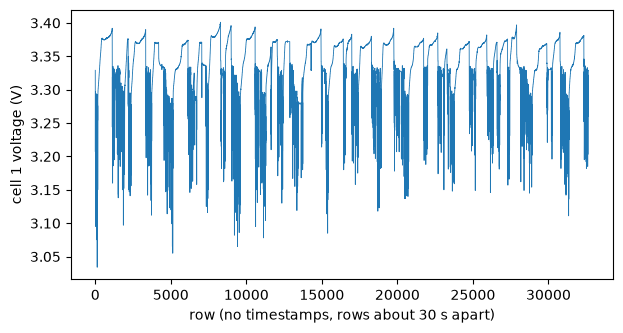

In [4]:
ax = frame['cell_v_001'].plot(figsize=(7, 3.5), lw=0.6, legend=False)
ax.set_xlabel('row (no timestamps, rows about 30 s apart)')
ax.set_ylabel('cell 1 voltage (V)')
plt.show()

Cell 1 of QAS vehicle 189 cycles between about 3.1 and 3.4 V over the record, with long charges rising to about 3.4 V. Row number stands in for time.